# Análise Exploratória de Dados (EDA): Preços de Combustíveis no Brasil (2018–2025)

* **Autor:** Carlos Henrique Freitas
* **Fonte de Dados:** [Série Histórica de Preços de Combustíveis e de GLP - ANP](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis)
* **Banco de Dados Origem:** PostgreSQL (`anp.preco_combustivel_brasil`)

---

## Descrição do Projeto
Este notebook contempla a etapa de saneamento, tratamento e Análise Exploratória de Dados (EDA) sobre a base histórica da ANP abrangendo o período de 2018 a 2025. O objetivo principal é identificar padrões de variação de preços, paridade entre combustíveis (Gasolina vs. Etanol) e discrepâncias regionais para posterior integração ao dashboard executivo.

---

## Sumário
1. [Setup e Conexão com o Banco de Dados](#setup)
2. [Inspeção Estrutural e Higienização de Dados](#higienizacao)
3. [Análise Exploratória e Hipóteses de Negócio](#eda)
4. [Síntese dos Achados e Recomendações de Negócio](#conclusao)

<a id="setup"></a>
## 1. Setup e Conexão com o Banco de Dados
Importação das bibliotecas essenciais para manipulação, estatística e visualização gráfica, além da inicialização da conexão com o PostgreSQL utilizando o módulo `config.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importação da função de conexão do arquivo config.py
from config import get_engine

# Ajustes gerais de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style="whitegrid")

# Criando o engine de conexão com o PostgreSQL
engine = get_engine()

# Teste simples de conexão
with engine.connect() as conn:
    print("Conexão com o PostgreSQL estabelecida com sucesso!")

Conexão com o PostgreSQL estabelecida com sucesso!


<a id="higienizacao"></a>
## 2. Inspeção Estrutural e Higienização de Dados
Validação de integridade dos registros carregados e investigação das incoerências mapeadas (como os 9.114 registros nulos).

### 2.1. Carga Inicial do Dataset no Pandas
Importação da tabela `anp.preco_combustivel_brasil` para um DataFrame e primeira visualização das 10 primeiras linhas da base.

In [2]:
# Carregando a base completa do PostgreSQL para o DataFrame 'df'
query = "SELECT * FROM anp.preco_combustivel_brasil;"
df = pd.read_sql(query, engine)

# Visualizando os 10 primeiros registros
df.head(10)

,regiao,estado,municipio,revenda,cnpj,nome_rua,numero_rua,complemento,bairro,cep,produto,data_coleta,valor_venda,valor_compra,unidade_medida,bandeira,data_ingestao
0,SE,SP,SANTOS,AUTO POSTO PRAIAMAR LTDA.,09.005.834/0001-64,AVENIDA PEDRO LESSA,1000,1010,PONTA DA PRAIA,11025-000,GASOLINA,2025-06-30,6.49,NaN,R$ / litro,VIBRA,2026-09-12 15:10:13.229804
1,SE,SP,SANTOS,AUTO POSTO PRAIAMAR LTDA.,09.005.834/0001-64,AVENIDA PEDRO LESSA,1000,1010,PONTA DA PRAIA,11025-000,GASOLINA ADITIVADA,2025-06-30,6.69,NaN,R$ / litro,VIBRA,2026-09-12 15:10:13.229804
2,SE,SP,SANTOS,AUTO POSTO PRAIAMAR LTDA.,09.005.834/0001-64,AVENIDA PEDRO LESSA,1000,1010,PONTA DA PRAIA,11025-000,ETANOL,2025-06-30,4.79,NaN,R$ / litro,VIBRA,2026-09-12 15:10:13.229804
3,S,RS,CRUZ ALTA,ABASTECEDORA DE COMBUSTÍVEIS DJ LTDA.,10.384.200/0003-00,AVENIDA SATURNINO DE BRITO,1177,NaN,VILA CONCEICAO,98040-070,GASOLINA,2025-06-30,6.39,NaN,R$ / litro,IPIRANGA,2026-09-12 15:10:13.229804
4,S,RS,CRUZ ALTA,ABASTECEDORA DE COMBUSTÍVEIS DJ LTDA.,10.384.200/0003-00,AVENIDA SATURNINO DE BRITO,1177,NaN,VILA CONCEICAO,98040-070,GASOLINA ADITIVADA,2025-06-30,6.59,NaN,R$ / litro,IPIRANGA,2026-09-12 15:10:13.229804
5,S,RS,CRUZ ALTA,ABASTECEDORA DE COMBUSTÍVEIS DJ LTDA.,10.384.200/0003-00,AVENIDA SATURNINO DE BRITO,1177,NaN,VILA CONCEICAO,98040-070,DIESEL,2025-06-30,6.29,NaN,R$ / litro,IPIRANGA,2026-09-12 15:10:13.229804
6,S,RS,CRUZ ALTA,ABASTECEDORA DE COMBUSTÍVEIS DJ LTDA.,10.384.200/0003-00,AVENIDA SATURNINO DE BRITO,1177,NaN,VILA CONCEICAO,98040-070,DIESEL S10,2025-06-30,6.39,NaN,R$ / litro,IPIRANGA,2026-09-12 15:10:13.229804
7,SE,RJ,RIO DE JANEIRO,AUTO POSTO GALEGO DO RIO DA PRATA LTDA,09.042.671/0001-90,ESTRADA DO CABUCU,1765,NaN,CAMPO GRANDE,23017-250,GASOLINA,2025-06-30,5.89,NaN,R$ / litro,BRANCA,2026-09-12 15:10:13.229804
8,SE,RJ,RIO DE JANEIRO,AUTO POSTO GALEGO DO RIO DA PRATA LTDA,09.042.671/0001-90,ESTRADA DO CABUCU,1765,NaN,CAMPO GRANDE,23017-250,GASOLINA ADITIVADA,2025-06-30,5.99,NaN,R$ / litro,BRANCA,2026-09-12 15:10:13.229804
9,SE,RJ,RIO DE JANEIRO,AUTO POSTO GALEGO DO RIO DA PRATA LTDA,09.042.671/0001-90,ESTRADA DO CABUCU,1765,NaN,CAMPO GRANDE,23017-250,DIESEL S10,2025-06-30,6.19,NaN,R$ / litro,BRANCA,2026-09-12 15:10:13.229804


### 2.2. Análise de Lacunas e Regra de Negócio
* **`complemento`:** Valores nulos esperados devido à variação de estruturas de endereço.
* **`valor_compra`:** Valores nulos considerados normais por não haver obrigatoriedade de repasse desse custo por parte dos postos à ANP.
* **Impacto:** Como o escopo do projeto foca na dinâmica do preço final de revenda (`valor_venda`), a ausência desses dois campos não afeta a análise.

In [3]:
# Verificação de nulos apenas nas colunas essenciais para as análises
colunas_criticas = ['regiao', 'estado', 'municipio', 'produto', 'data_coleta', 'valor_venda']
df[colunas_criticas].isnull().sum()

regiao         9114
estado         9114
municipio      9114
produto        9114
data_coleta    9114
valor_venda    9114
dtype: int64

### 2.3. Remoção dos Registros Inconsistentes no DataFrame
Com base na verificação, as 9.114 linhas com valores nulos nas colunas fundamentais serão descartadas do DataFrame principal.

In [4]:
# Eliminando as linhas com nulos nas colunas críticas
df = df.dropna(subset=['produto', 'valor_venda']).copy()

# Validação do novo shape do DataFrame
print(f"Dimensão atualizada do DataFrame: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")

# Confirmação de nulos restantes nas colunas críticas
df[['regiao', 'estado', 'municipio', 'produto', 'data_coleta', 'valor_venda']].isnull().sum()

Dimensão atualizada do DataFrame: 7,008,523 linhas e 17 colunas.


regiao         0
estado         0
municipio      0
produto        0
data_coleta    0
valor_venda    0
dtype: int64

### 2.4. Verificação dos Tipos de Dados e Consumo de Memória
Inspeção dos tipos de dados (`dtypes`) atribuídos a cada coluna pelo Pandas para garantir que variáveis numéricas, temporais e categóricas estejam nos formatos adequados.

In [5]:
# Inspeção detalhada de colunas, tipos de dados e memória
df.info()

<class 'pandas.DataFrame'>
Index: 7008523 entries, 0 to 7017636
Data columns (total 17 columns):
 #   Column          Dtype         
---  ------          -----         
 0   regiao          str           
 1   estado          str           
 2   municipio       str           
 3   revenda         str           
 4   cnpj            str           
 5   nome_rua        str           
 6   numero_rua      str           
 7   complemento     str           
 8   bairro          str           
 9   cep             str           
 10  produto         str           
 11  data_coleta     object        
 12  valor_venda     float64       
 13  valor_compra    float64       
 14  unidade_medida  str           
 15  bandeira        str           
 16  data_ingestao   datetime64[us]
dtypes: datetime64[us](1), float64(2), object(1), str(13)
memory usage: 962.5+ MB


### 2.5. Conversão de Tipos de Dados
A coluna `data_coleta` foi importada como tipo `object` (texto). Para viabilizar a manipulação temporal, cálculos de variação de preços ao longo dos anos e agrupamentos por períodos no Pandas, o campo será convertido para o formato `datetime64`.

In [6]:
# Conversão da coluna data_coleta para o tipo datetime
df['data_coleta'] = pd.to_datetime(df['data_coleta'])

# Validação da conversão realizada
print(f"Novo tipo de dado de 'data_coleta': {df['data_coleta'].dtype}")
df[['data_coleta']].head()

Novo tipo de dado de 'data_coleta': datetime64[s]


,data_coleta
0,2025-06-30
1,2025-06-30
2,2025-06-30
3,2025-06-30
4,2025-06-30


### 2.6. Validação do Período Temporal e Categorias de Produtos
Inspeção do limite temporal (data mínima e máxima) para confirmar a cobertura dos anos de 2018 a 2025 e verificação dos valores únicos na coluna `produto` para mapear possíveis divergências cadastrais.

In [7]:
# Verificação do intervalo temporal
data_min = df['data_coleta'].min().strftime('%d/%m/%Y')
data_max = df['data_coleta'].max().strftime('%d/%m/%Y')

print(f"Período temporal da base: {data_min} até {data_max}")

# Inspeção dos produtos registrados
print("\nProdutos mapeados no dataset:")
print(df['produto'].unique())

Período temporal da base: 01/01/2018 até 31/12/2025

Produtos mapeados no dataset:
<StringArray>
['GASOLINA', 'GASOLINA ADITIVADA', 'ETANOL', 'DIESEL', 'DIESEL S10', 'GNV']
Length: 6, dtype: str


### 2.7. Validação das Categorias de Produtos
As 6 categorias de combustíveis estão padronizadas sem problemas de inconsistência textual. A cobertura temporal abrange integralmente o período de 01/01/2018 a 31/12/2025.

<a id="eda"></a>
## 3. Análise Exploratória e Hipóteses de Negócio
Início da exploração estatística para entender a distribuição dos preços, variações por produto e comportamento temporal.

### 3.1. Panorama Estatístico de Preços por Produto
Resumo estatístico das métricas centrais e de dispersão (média, desvio padrão, mínimo, quartis e máximo) do preço de venda para cada tipo de combustível.

In [8]:
# Tabela resumo de estatísticas descritivas por produto
resumo_produtos = df.groupby('produto')['valor_venda'].agg(
    registros='count',
    media='mean',
    mediana='median',
    std='std',
    minimo='min',
    maximo='max'
).reset_index()

# Ordenando pela média de preço decrescente
resumo_produtos.sort_values(by='media', ascending=False)

,produto,registros,media,mediana,std,minimo,maximo
4,GASOLINA ADITIVADA,867576,6.13,6.09,0.72,3.46,9.79
3,GASOLINA,1924598,5.31,5.25,0.97,2.87,9.29
1,DIESEL S10,1487911,4.90,4.69,1.33,2.46,9.65
0,DIESEL,918423,4.76,4.43,1.33,2.45,9.00
5,GNV,132011,4.11,4.29,0.95,1.76,7.99
2,ETANOL,1678004,3.87,3.79,0.89,1.80,7.98


### 3.2. Interpretação dos Resultados Estatísticos
* A **Gasolina Comum** lidera a representatividade na base (1.924.598 registros), acompanhada pelo **Etanol** (1.678.004) e **Diesel S10** (1.487.911). O **GNV** apresenta a menor amostragem (132.011 registros), refletindo a menor disponibilidade de infraestrutura de postos com suporte a gás natural veicular no território nacional.

* A **Gasolina Aditivada** registra o maior valor médio (R$ 6,13/L), atingindo o pico de R$ 9,79/L no período. O **Etanol** apresenta a menor média absoluta por litro (R$ 3,87/L).

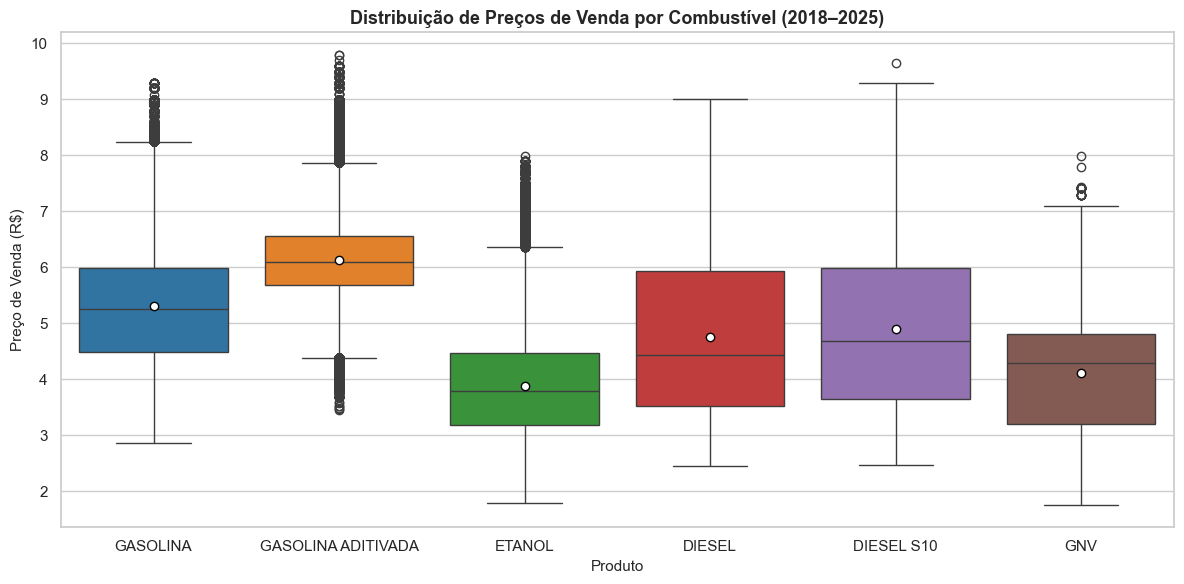

In [10]:
# Gráficos de distribuição e amplitude de preços por combustível
plt.figure(figsize=(12, 6))

# Boxplot para identificar mediana, quartis e outliers
sns.boxplot(
    data=df, 
    x='produto', 
    y='valor_venda',
    hue='produto',
    palette='tab10',
    legend=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

plt.title('Distribuição de Preços de Venda por Combustível (2018–2025)', fontsize=13, fontweight='bold')
plt.xlabel('Produto', fontsize=11)
plt.ylabel('Preço de Venda (R$)', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3. Análise da Distribuição e Identificação de Outliers
* O **Diesel** e o **Diesel S10** apresentam maior amplitude interquartil (caixa mais larga), demonstrando forte oscilação de preços ao longo dos anos, com limites superiores ultrapassando R$ 9,00/L sem a geração expressiva de *outliers* isolados.

* ** **Gasolina Comum**, **Gasolina Aditivada** e **Etanol** exibem grande densidade de *outliers* no limite superior, com valores atingindo picos próximos de R$ 9,80/L.

* **Hipóteses Analíticas:**

  1. **Distorção Temporal (Efeito Macroeconômico):** Efeitos inflacionários pós-pandemia (2021–2022) e choques na cotação internacional do petróleo PPI (*Preço de Paridade de Importação*).
  2. **Distorção Geográfica (Logística):** Custo de frete elevado para regiões de difícil acesso (como o interior da Região Norte) e disparidades estaduais de ICMS.

In [11]:
# Criando a coluna 'ano' para facilidade de agrupamento
df['ano'] = df['data_coleta'].dt.year

# Agrupando preço médio por ano e produto
preco_anual = df.groupby(['ano', 'produto'])['valor_venda'].mean().unstack()

# Exibição da tabela dinâmica de preços médios
preco_anual

produto,DIESEL,DIESEL S10,ETANOL,GASOLINA,GASOLINA ADITIVADA,GNV
ano,,,,,,
2018,3.50,3.59,3.13,4.45,NaN,2.73
2019,3.60,3.69,3.17,4.42,NaN,3.22
2020,3.42,3.51,3.18,4.28,4.59,3.17
2021,4.69,4.74,4.67,5.89,6.04,3.89
2022,6.63,6.73,4.85,6.32,6.47,5.04
2023,5.76,5.86,4.00,5.53,5.71,4.64
2024,5.97,6.03,4.07,5.93,6.12,4.77
2025,6.15,6.21,4.46,6.25,6.45,4.74


### 3.4. Evolução Temporal dos Preços Médios (2018–2025)
* **Período Pré-Pandemia e Impacto Inicial (2018–2020):** Estabilidade nos preços médios, com leve retração em 2020 provocada pela queda abrupta na demanda durante os primeiros meses da pandemia de COVID-19 (Gasolina cedeu de R$ 4,45 para R$ 4,28; Diesel de R$ 3,50 para R$ 3,42).

* **Escalada Pós-Pandemia (2021–2022):** Forte reajuste em todas as categorias. O Diesel S10 teve alta expressiva, saltando de R$ 3,51 (2020) para R$ 6,73 (2022), impulsionado pela volatilidade das commodities globais e câmbio.

* **Nota Metodológica da ANP:** A ausência de registros (`NaN`) para a **Gasolina Aditivada** nos anos de 2018 e 2019 decorre do início da discriminação desse combustível na base pública a partir de 2020.

### 3.6. Análise Geográfica: Preços Médios por Região e Estado
Investigação das disparidades regionais no preço dos combustíveis para identificar o impacto logístico e tributário em cada macro-região e nos Estados brasileiros.

In [12]:
# Tabela dinâmica de preço médio por Região e Produto
preco_regiao = df.groupby(['regiao', 'produto'])['valor_venda'].mean().unstack()
preco_regiao

produto,DIESEL,DIESEL S10,ETANOL,GASOLINA,GASOLINA ADITIVADA,GNV
regiao,,,,,,
CO,4.84,4.94,3.66,5.32,6.11,3.70
N,5.19,5.27,4.47,5.56,6.41,4.16
NE,4.79,4.91,4.24,5.38,6.21,4.03
S,4.74,4.82,4.09,5.29,6.10,4.30
SE,4.65,4.86,3.68,5.25,6.06,4.10


In [13]:
# Ranking dos Estados por preço médio da Gasolina Comum
gasolina_estados = df[df['produto'] == 'GASOLINA'].groupby('estado')['valor_venda'].mean().sort_values(ascending=False)

print("--- TOP 5 ESTADOS COM GASOLINA MAIS CARA ---")
print(gasolina_estados.head(5))

print("\n--- TOP 5 ESTADOS COM GASOLINA MAIS BARATA ---")
print(gasolina_estados.tail(5))

--- TOP 5 ESTADOS COM GASOLINA MAIS CARA ---
estado
AC   5.91
AM   5.65
RO   5.58
PA   5.57
RJ   5.57
Name: valor_venda, dtype: float64

--- TOP 5 ESTADOS COM GASOLINA MAIS BARATA ---
estado
MS   5.21
MA   5.20
SC   5.16
SP   5.10
AP   4.81
Name: valor_venda, dtype: float64


### 3.7. Interpretação da Variabilidade Geográfica e Impacto Tributário
* Os estados da Região Norte (AC: R$ 5,91; AM: R$ 5,65; RO: R$ 5,58) lideram o ranking de preços médios mais elevados devido aos altos custos de frete fluvial/rodoviário e dependência de suprimento externo.

* O estado do RJ figura no TOP 5 dos mais caros do país (R$ 5,57/L) a par de estados amapaenses e amazônicos, demonstrando que a **carga tributária estadual (ICMS elevado)** suplantou a vantagem logística de produção da Bacia de Campos/Santos.

* São Paulo (R$ 5,10/L) e Mato Grosso do Sul (R$ 5,21/L) apresentam as menores médias operacionais, favorecidos pela ampla malha de refinarias e concorrência na distribuição.

### 3.8. Visualização Comparativa: Estados Extremos (Gasolina Comum)
Gráfico de barras destacando os 5 estados com maiores médias de preço de venda e os 5 estados com menores médias para evidenciar o contraste regional e fiscal no país.

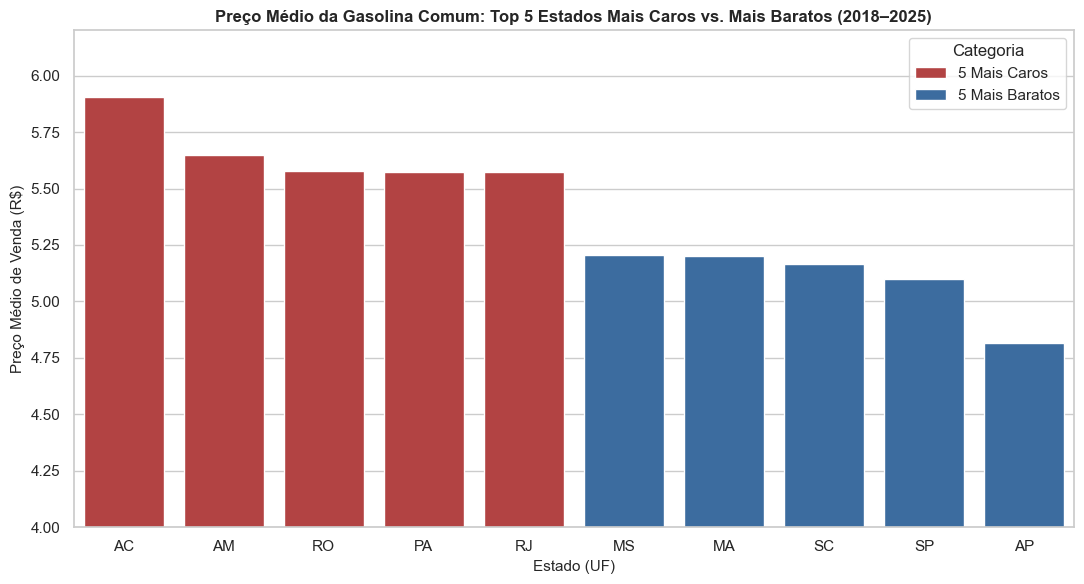

In [15]:
# Seleção dos 5 mais caros e 5 mais baratos
top5_caros = gasolina_estados.head(5).reset_index()
top5_caros['grupo'] = '5 Mais Caros'

top5_baratos = gasolina_estados.tail(5).reset_index()
top5_baratos['grupo'] = '5 Mais Baratos'

# Consolidação e ordenação do maior para o menor preço
df_comparativo = pd.concat([top5_caros, top5_baratos]).sort_values(by='valor_venda', ascending=False)

# Plotagem do gráfico de barras verticais
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_comparativo,
    x='estado',
    y='valor_venda',
    hue='grupo',
    palette={'5 Mais Caros': '#C53030', '5 Mais Baratos': '#2B6CB0'},
    dodge=False
)

plt.title('Preço Médio da Gasolina Comum: Top 5 Estados Mais Caros vs. Mais Baratos (2018–2025)', fontsize=12, fontweight='bold')
plt.xlabel('Estado (UF)', fontsize=11)
plt.ylabel('Preço Médio de Venda (R$)', fontsize=11)
plt.ylim(4.0, 6.2)
plt.legend(title='Categoria', loc='upper right')
plt.tight_layout()
plt.show()

### 3.9. Insights do Comparativo Estadual
* **Extrema Disparidade no Acre (AC):** Registrou a maior média histórica nacional (R$ 5,91/L), evidenciando o impacto conjunto de gargalos logísticos e fretes de longa distância.

* **Exceção do Amapá (AP):** Apesar da localização geográfica na Região Norte, registrou a menor média nacional (R$ 4,81/L), beneficiado por incentivos fiscais e regimes de Livre Comércio.

* **Amplitude de Preço:** A variação de mais de R$ 1,10/L entre os extremos estaduais demonstra como a combinação de ICMS local e logística afeta o consumidor final.

### 3.10. Análise de Competitividade: Paridade Etanol vs. Gasolina
Investigação da relação de preço entre o Etanol e a Gasolina Comum. Segundo a regra de eficiência energética dos motores flex, abastecer com Etanol é financeiramente vantajoso quando a razão $\frac{\text{Preço Etanol}}{\text{Preço Gasolina}}$ for inferior a **0,70 (70%)**.

In [16]:
# Isolando Gasolina Comum e Etanol
df_paridade = df[df['produto'].isin(['GASOLINA', 'ETANOL'])].copy()

# Agrupando preços médios anuais
paridade_anual = df_paridade.groupby(['ano', 'produto'])['valor_venda'].mean().unstack()

# Criando as colunas de razão e decisão econômica
paridade_anual['razao_etanol_gasolina'] = paridade_anual['ETANOL'] / paridade_anual['GASOLINA']
paridade_anual['combustivel_vantajoso'] = paridade_anual['razao_etanol_gasolina'].apply(
    lambda x: 'Etanol' if x < 0.70 else 'Gasolina'
)

paridade_anual[['ETANOL', 'GASOLINA', 'razao_etanol_gasolina', 'combustivel_vantajoso']]

produto,ETANOL,GASOLINA,razao_etanol_gasolina,combustivel_vantajoso
ano,,,,
2018,3.13,4.45,0.70,Gasolina
2019,3.17,4.42,0.72,Gasolina
2020,3.18,4.28,0.74,Gasolina
2021,4.67,5.89,0.79,Gasolina
2022,4.85,6.32,0.77,Gasolina
2023,4.00,5.53,0.72,Gasolina
2024,4.07,5.93,0.69,Etanol
2025,4.46,6.25,0.71,Gasolina


### 3.11. Interpretação da Paridade Média Nacional
* **Resultado Consolidado:** Na média nacional agregada, a Gasolina Comum foi o combustível predominantemente vantajoso entre 2018 e 2025, com a paridade do Etanol caindo abaixo do limite de 70% apenas em **2024 (0,69)**.

* **Vieses de Agregação:** A média nacional mascara a competitividade do Etanol em polos sucroalcooleiros. O custo de frete interestadual para regiões não produtoras inflaciona o preço médio do Etanol no indicador consolidado.

In [17]:
# Agrupando por estado e produto para calcular a paridade média local
paridade_estado = df_paridade.groupby(['estado', 'produto'])['valor_venda'].mean().unstack()

# Calculando a razão por estado
paridade_estado['razao'] = paridade_estado['ETANOL'] / paridade_estado['GASOLINA']
paridade_estado['vantajoso'] = paridade_estado['razao'].apply(lambda x: 'Etanol' if x < 0.70 else 'Gasolina')

# Exibindo os 5 estados onde o Etanol é mais competitivo
print("--- TOP 5 ESTADOS COM ETANOL MAIS COMPETITIVO ---")
paridade_estado.sort_values(by='razao')[['ETANOL', 'GASOLINA', 'razao', 'vantajoso']].head(5)

--- TOP 5 ESTADOS COM ETANOL MAIS COMPETITIVO ---


produto,ETANOL,GASOLINA,razao,vantajoso
estado,,,,
MT,3.40,5.25,0.65,Etanol
SP,3.47,5.10,0.68,Etanol
GO,3.67,5.39,0.68,Etanol
MG,3.73,5.43,0.69,Etanol
PR,3.75,5.24,0.72,Gasolina


### 3.12. Confirmação da Competitividade Regional do Etanol
* **Estados onde o Etanol é Vantajoso (Razão < 0,70):** Mato Grosso (0,65), São Paulo (0,68), Goiás (0,68) e Minas Gerais (0,69).

* **Fator Econômico:** A alta concentração de usinas sucroalcooleiras no Sudeste e o avanço do etanol de milho no Centro-Oeste garantem preços competitivos na bomba nessas Unidades Federativas.

* **Fronteira de Atratividade:** O Paraná (PR = 0,72) atua como zona de transição, enquanto estados do Norte, Nordeste e Sul dependem de frete de longa distância, inviabilizando a paridade do Etanol no acumulado histórico.

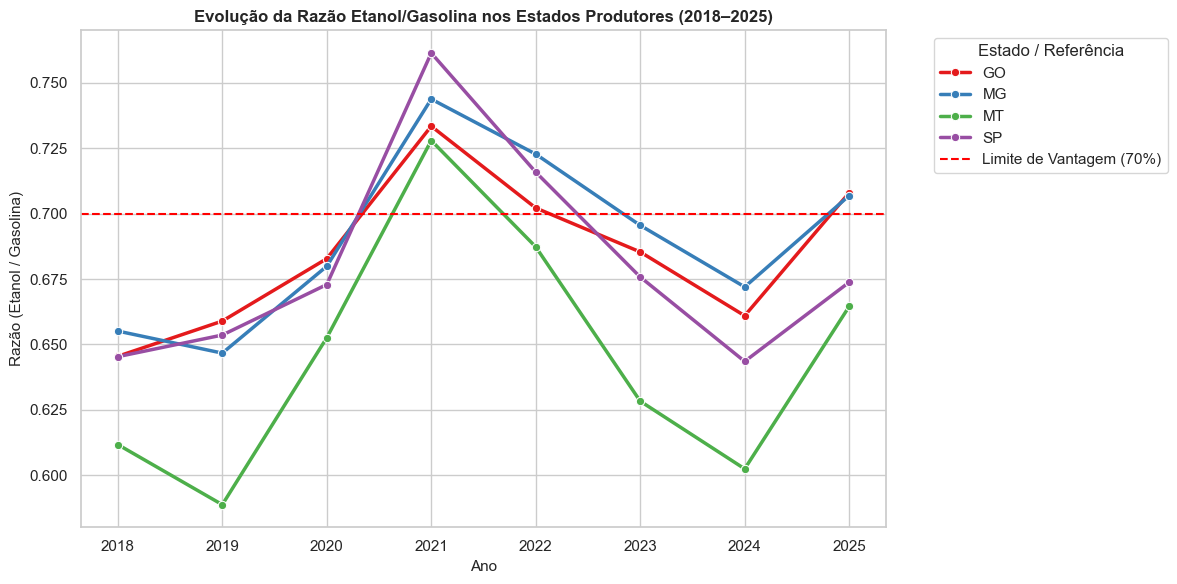

In [18]:
# Filtrando os estados produtores e calculando a paridade anual por estado
estados_produtores = ['MT', 'SP', 'GO', 'MG']
df_par_est = df_paridade[df_paridade['estado'].isin(estados_produtores)]

paridade_temporal_est = df_par_est.groupby(['ano', 'estado', 'produto'])['valor_venda'].mean().unstack()
paridade_temporal_est['razao'] = paridade_temporal_est['ETANOL'] / paridade_temporal_est['GASOLINA']
paridade_temporal_est = paridade_temporal_est.reset_index()

# Plotagem do gráfico de linhas de paridade temporal por estado
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=paridade_temporal_est,
    x='ano',
    y='razao',
    hue='estado',
    marker='o',
    palette='Set1',
    linewidth=2.5
)

# Linha de referência da regra dos 70%
plt.axhline(0.70, color='red', linestyle='--', linewidth=1.5, label='Limite de Vantagem (70%)')

plt.title('Evolução da Razão Etanol/Gasolina nos Estados Produtores (2018–2025)', fontsize=12, fontweight='bold')
plt.xlabel('Ano', fontsize=11)
plt.ylabel('Razão (Etanol / Gasolina)', fontsize=11)
plt.legend(title='Estado / Referência', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.13. Dinâmica Temporal da Paridade nos Estados Produtores
* **A Anomalia de 2021:** Em 2021, a razão superou o teto de 0,70 em **todos** os estados produtores (SP atingiu ~0,76; MG ~0,74; GO e MT ~0,73). O choque nos preços das commodities e a dinâmica de mercado sucroalcooleiro (preferência pela produção de açúcar em detrimento do etanol) tornaram a Gasolina temporariamente mais vantajosa até mesmo nos principais polos produtivos.
* **Liderança Absoluta do Mato Grosso (MT):** MT manteve-se como o estado de maior competitividade do Etanol em quase todo a série histórica, registrando vales de até 0,59 (2019) e 0,60 (2024), impulsionado pela expansão das usinas de etanol de milho.
* **Ciclo de Recuperação (2023–2024):** A partir de 2023, os quatro estados retornaram à zona de atratividade do Etanol (< 0,70), com destaque para 2024, onde SP (0,64) e GO (0,66) atingiram nova janela de alta eficiência econômica para o consumidor.

<a id="conclusao"></a>
## 4. Síntese dos Achados e Recomendações de Negócio

### 4.1. Resumo Executivo das Hipóteses Testadas
1. **Comportamento Temporal e Choques Macroeconômicos:** A série de preços (2018–2025) reflete clivagens claras em eventos como a crise de mobilidade de 2020 (pandemia) e o pico inflacionário de 2021–2022. O Diesel atingiu ápice de R$ 6,73/L em 2022 impulsionado por tensões geopolíticas no mercado internacional do petróleo.

2. **Disparidade Geográfica vs. Carga Tributária:** A Região Norte apresentou as maiores médias devido a custos logísticos e fretes de longa distância (AC atingiu R$ 5,91/L). O Rio de Janeiro (RJ) destacou-se no Sudeste (R$ 5,57/L) devido à alta alíquota histórica de ICMS, superando barreiras de proximidade da produção refinadora.

3. **Métrica de Paridade Etanol vs. Gasolina:** A média nacional mascarava a atratividade do Etanol (que só ficou abaixo de 0,70 em 2024). A desagregação estadual provou que em polos produtores (MT, SP, GO, MG) o Etanol foi predominantemente a escolha mais eficiente em quase todos os anos, com exceção do choque atípico de 2021.

### 4.2. Recomendações Estratégicas de Negócio
1. **Gestão de Frotas e Matriz de Abastecimento:** Implementar política de abastecimento regionalizada para veículos *flex*. Frotas operando no Sudeste e Centro-Oeste (principalmente em MT, SP, GO e MG) devem priorizar o Etanol, enquanto operações nas regiões Norte, Nordeste e Sul devem manter a Gasolina como combustível padrão.

2. **Monitoramento Tributário e Fiscal:** Acompanhar continuamente alterações nas alíquotas estaduais de ICMS e desonerações federais. Conforme observado no caso do Rio de Janeiro, variações fiscais locais têm impacto direto na viabilidade econômica operacional superior ao fator de proximidade logística.

3. **Mitigação de Riscos no Modulo Rodoviário (Diesel):** Estabelecer cláusulas contratuais de frete com gatilhos de reajuste atrelados à variação do Diesel S10, protegendo a operação contra choques geopolíticos no mercado internacional do petróleo.